In [33]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Mengubah tingkat kecerahan citra
---------------------------------
Masukkan nilai kecerahan: 30


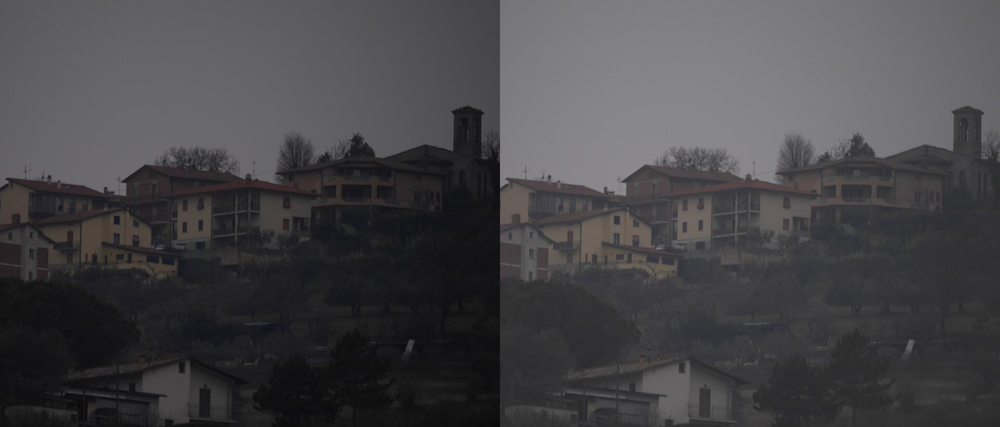

In [35]:
print(' Mengubah tingkat kecerahan citra')
print('---------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

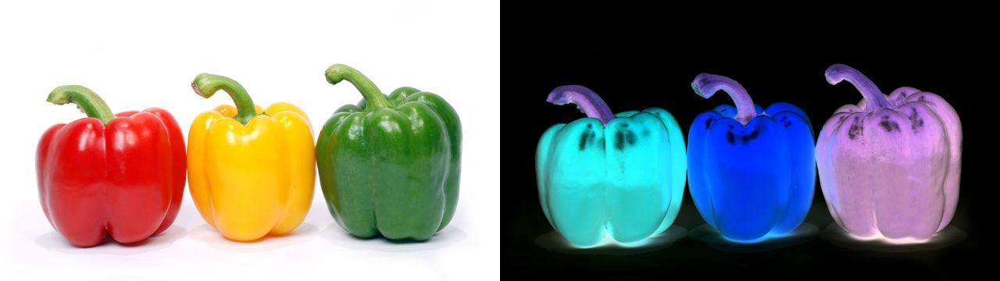

In [36]:
original = cv.imread('paprika.jpg')

inverse_image = 255-original

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

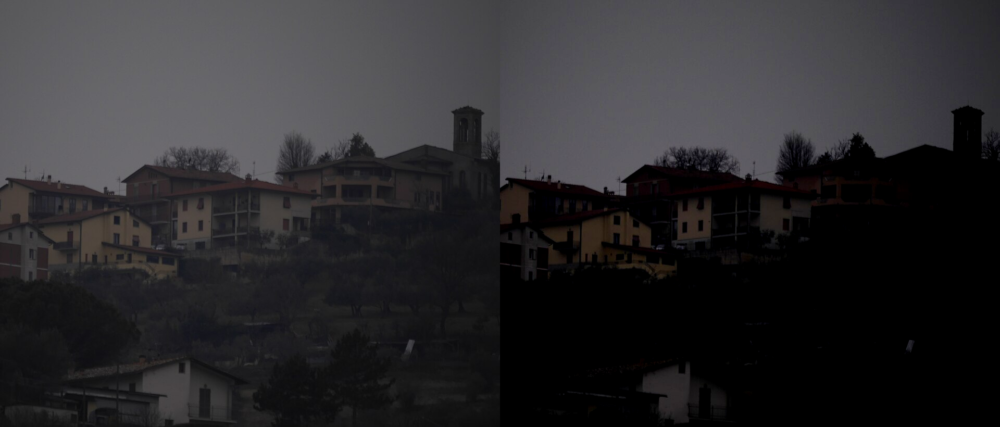

In [37]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')

contrast = 50
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

contrast_image = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            val = factor * (int(original[y, x, c]) - 128) + 128
            contrast_image[y, x, c] = np.clip(val, 0, 255)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

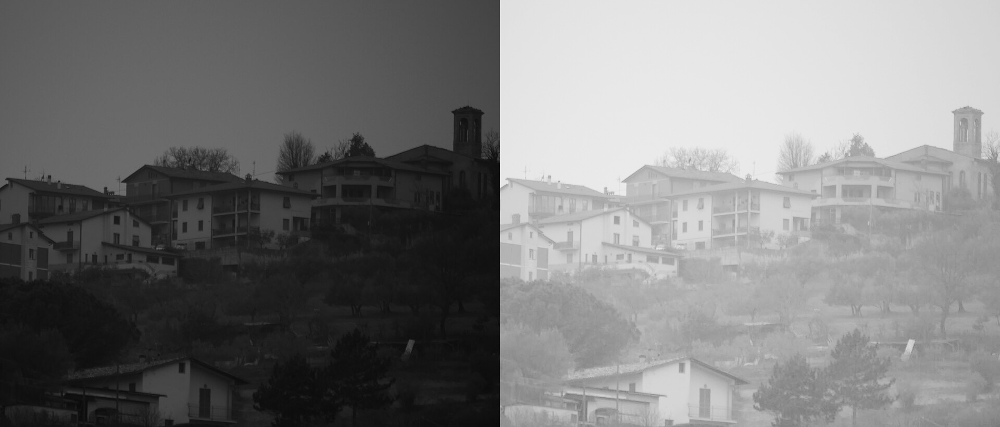

In [38]:
original_gray = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg', cv.IMREAD_GRAYSCALE)

c = 50
img_float = original_gray.astype(float)
log_image = c * np.log(1 + img_float)
log_image = np.uint8(np.clip(log_image, 0, 255))

final_frame = cv.hconcat((original_gray, log_image))
cv2_imshow(final_frame)

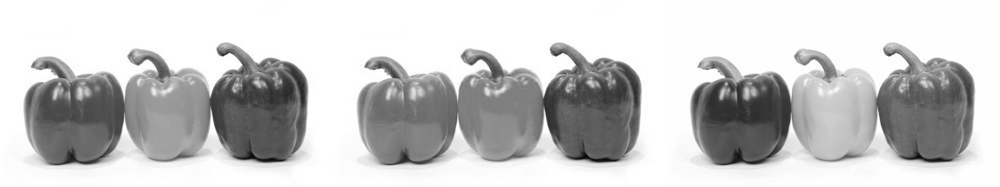

In [39]:
original = cv.imread('paprika.jpg')
R = original[:, :, 2].astype(float)
G = original[:, :, 1].astype(float)
B = original[:, :, 0].astype(float)

gray_avg = np.uint8((R + G + B) / 3)

max_rgb = np.maximum(np.maximum(R, G), B)
min_rgb = np.minimum(np.minimum(R, G), B)
gray_lightness = np.uint8((max_rgb + min_rgb) / 2)

gray_luminance = np.uint8(0.21 * R + 0.72 * G + 0.07 * B)

final_frame = cv.hconcat((gray_avg, gray_lightness, gray_luminance))
cv2_imshow(final_frame)

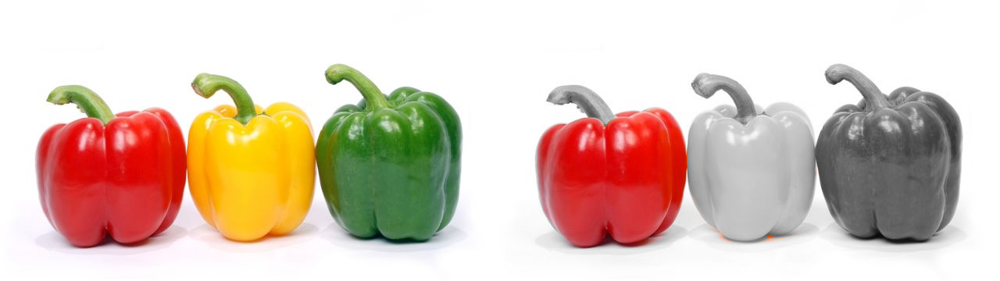

In [40]:
original = cv.imread('paprika.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
mask = mask1 + mask2

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_3channel = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

extracted_red = np.where(mask[:, :, np.newaxis] == 255, original, gray_3channel)

final_frame = cv.hconcat((original, extracted_red))
cv2_imshow(final_frame)

 Gamma Correction pada citra 
------------------------------
Masukkan nilai Gamma: 5


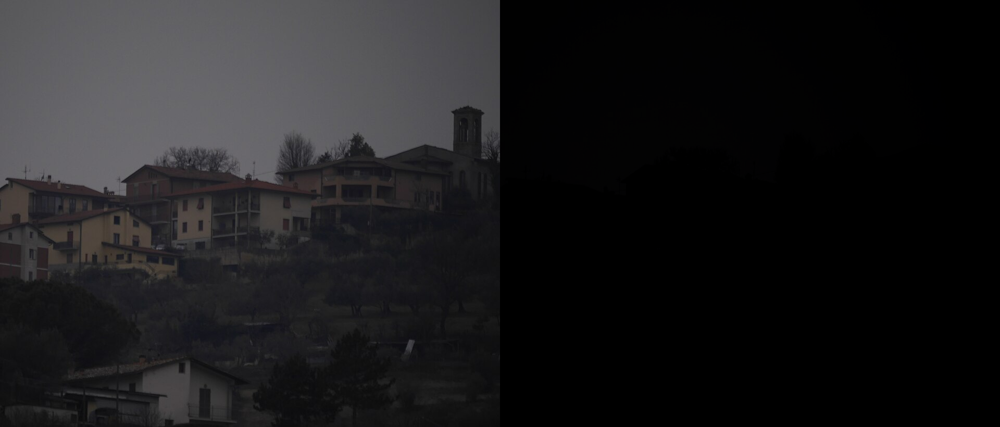

In [49]:
print(' Gamma Correction pada citra ')
print('------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    gamma = 2.2 # Default jika error

original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')

normalized = original / 255.0
gamma_image = np.power(normalized, gamma) * 255.0
gamma_image = np.uint8(np.clip(gamma_image, 0, 255))

final_frame = cv.hconcat((original, gamma_image))
cv2_imshow(final_frame)

Masukkan bit depth tujuan (1-8): 4
Bit depth awal : 8 bit
Bit depth tujuan: 4 bit
Jumlah level   : 16


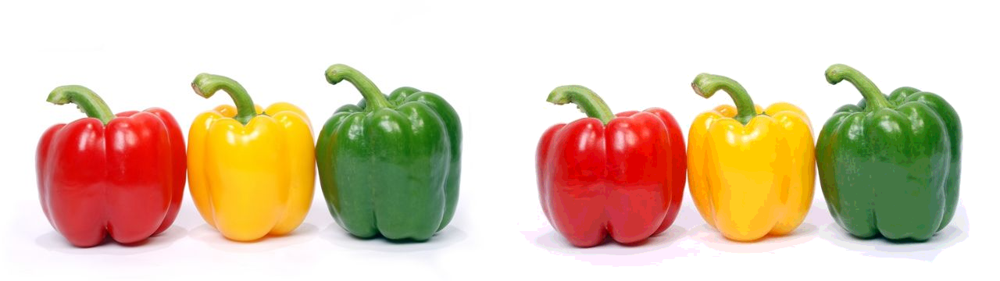

In [48]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    bit_depth = 3

level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('paprika.jpg')
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        depth_image[y, x] = np.round(original[y, x] / level) * level

depth_image = np.uint8(depth_image)

print(f"Bit depth awal : 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level   : {int(pow(2, bit_depth))}")

final_frame = cv.hconcat((original, depth_image))
cv2_imshow(final_frame)

In [43]:
cv_img.append(cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg'))

jumlah_citra = 10
accumulator = cv_img[0].astype(float)

for i in range(1, jumlah_citra):
    accumulator += cv_img[i].astype(float)

avg_image = accumulator / jumlah_citra
avg_image = np.uint8(np.clip(avg_image, 0, 255))

print(f"Hasil Average Denoising dengan {jumlah_citra} citra:")
cv2_imshow(avg_image)

NameError: name 'cv_img' is not defined

Hasil Average Denoising dengan 10 citra:


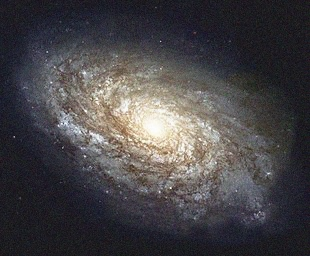

In [47]:
cv_img = [
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/1.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/2.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/3.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/4.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/5.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/6.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/7.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/8.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/9.jpg'),
    cv.imread('/content/drive/MyDrive/PCVK/Images/noises/10.jpg')
]

jumlah_citra = 10

accumulator = cv_img[0].astype(float)

for i in range(1, jumlah_citra):
    accumulator += cv_img[i].astype(float)

avg_image = accumulator / jumlah_citra
avg_image = np.uint8(np.clip(avg_image, 0, 255))

print(f"Hasil Average Denoising dengan {jumlah_citra} citra:")
cv2_imshow(avg_image)

--- 1. Operator NOT (Komplemen) ---


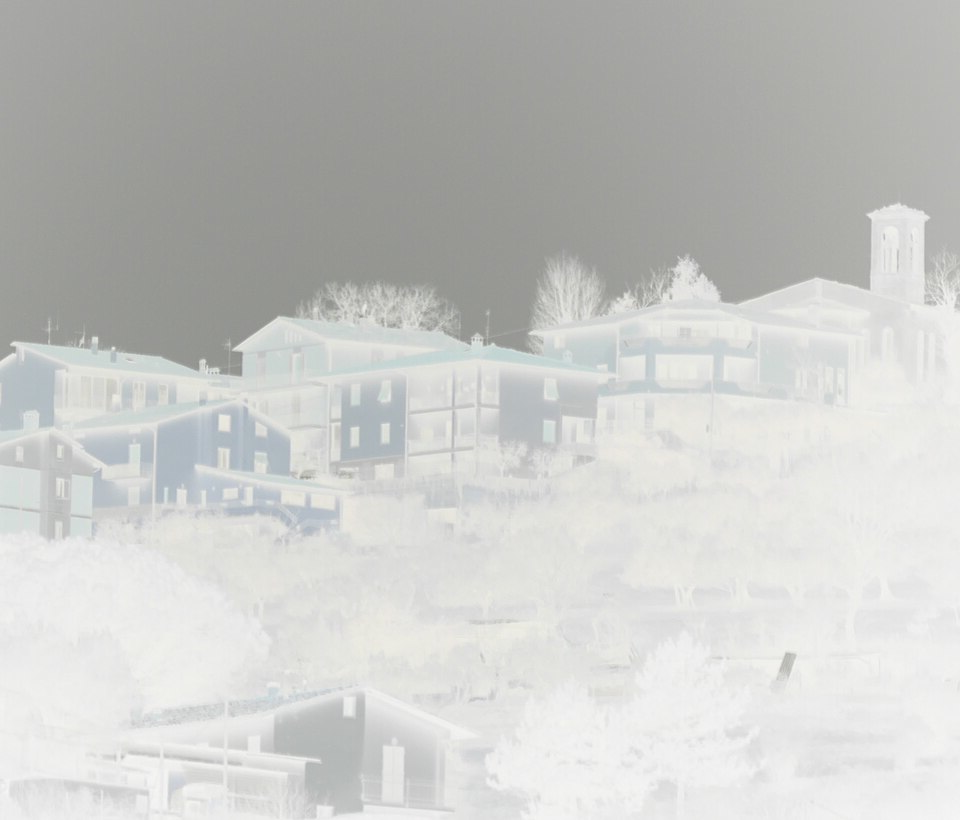

--- 2. Operator OR ---


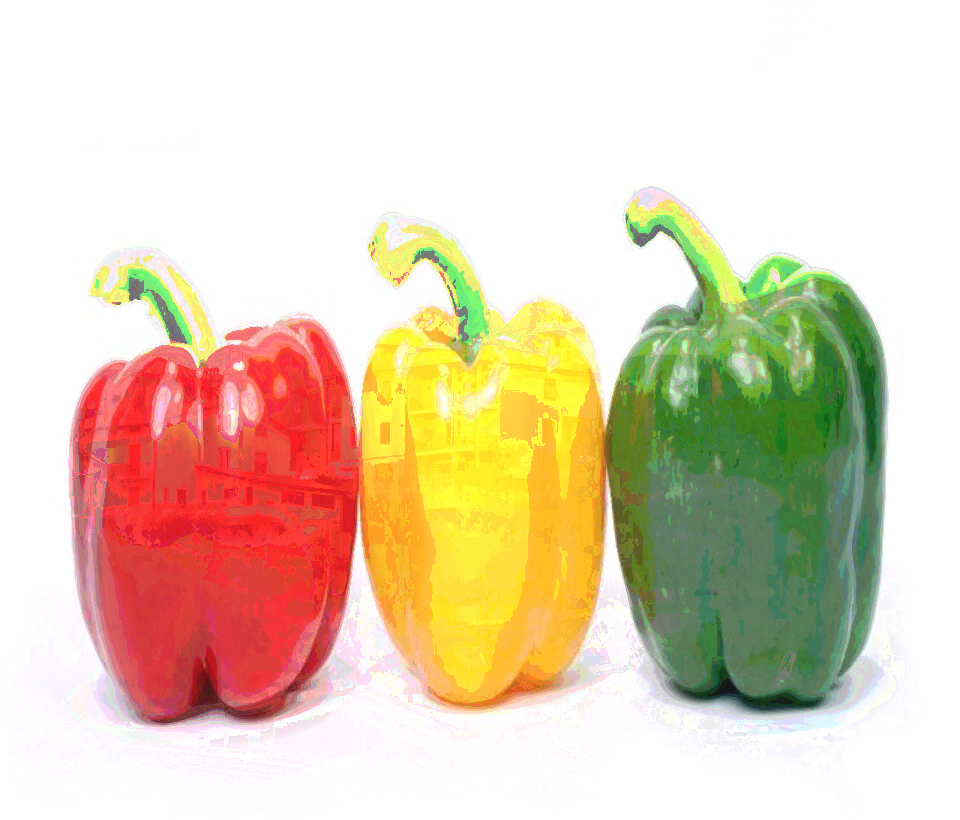

--- 3. Operator AND ---


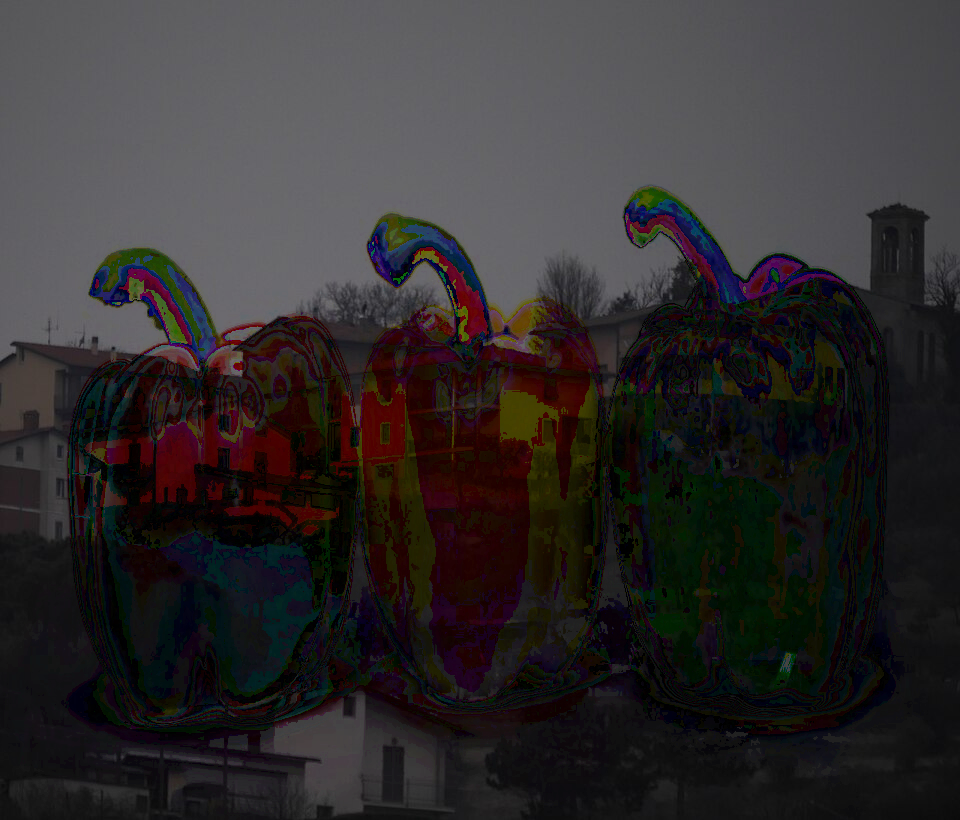

--- 4. Operator NAND ---


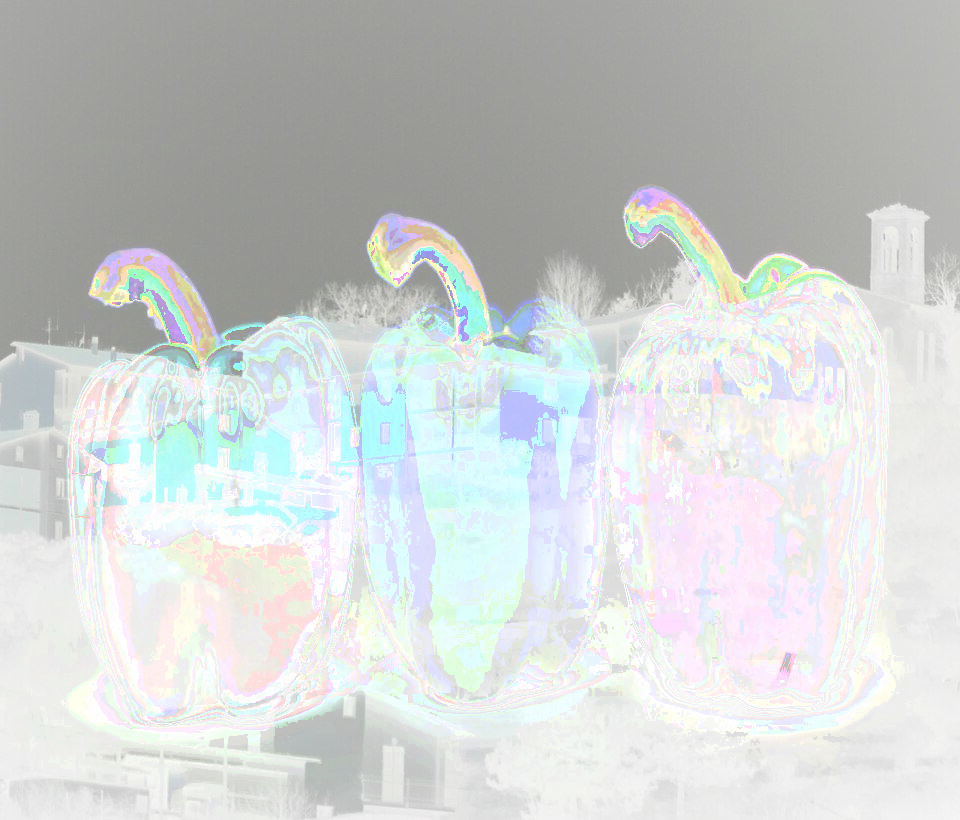

--- 5. Operator XOR ---


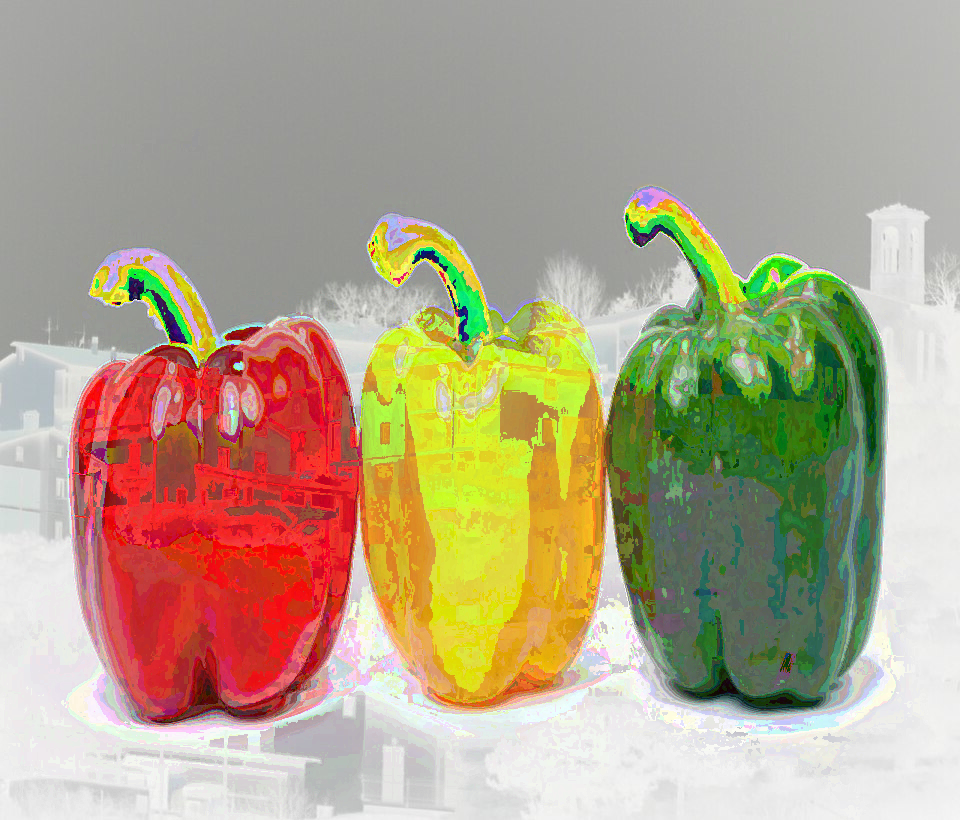

In [51]:
img1 = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
img2 = cv.imread('paprika.jpg')

img2 = cv.resize(img2, (img1.shape[1], img1.shape[0]))

not_img = cv.bitwise_not(img1)
or_img = cv.bitwise_or(img1, img2)
and_img = cv.bitwise_and(img1, img2)
nand_img = cv.bitwise_not(and_img)
xor_img = cv.bitwise_xor(img1, img2)

print("--- 1. Operator NOT (Komplemen) ---")
cv2_imshow(not_img)

print("--- 2. Operator OR ---")
cv2_imshow(or_img)

print("--- 3. Operator AND ---")
cv2_imshow(and_img)

print("--- 4. Operator NAND ---")
cv2_imshow(nand_img)

print("--- 5. Operator XOR ---")
cv2_imshow(xor_img)

Perbandingan: Citra Asli (Gelap) vs Hasil Perbaikan Gamma Correction


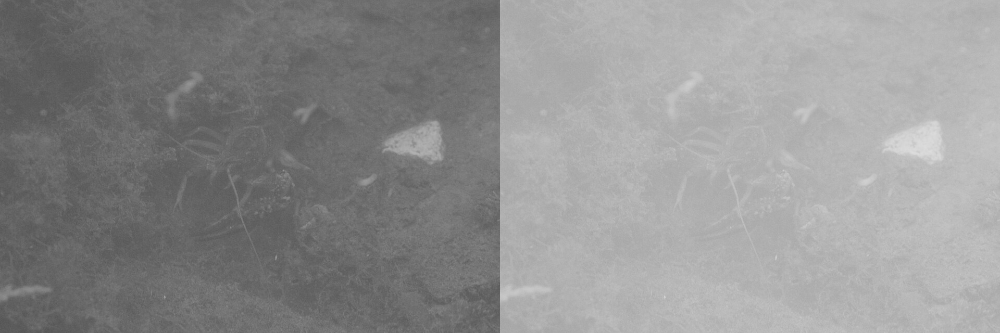

In [52]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/crayfish.jpg', cv.IMREAD_GRAYSCALE) # Bisa diganti path foto malam

gamma = 0.4
normalized = original / 255.0
gamma_image = np.power(normalized, gamma) * 255.0
gamma_image = np.uint8(np.clip(gamma_image, 0, 255))

final_frame = cv.hconcat((original, gamma_image))
print("Perbandingan: Citra Asli (Gelap) vs Hasil Perbaikan Gamma Correction")
cv2_imshow(final_frame)

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/crayfish.jpg')

contrast = 60
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

contrast_image = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            val = factor * (int(original[y, x, c]) - 128) + 128
            contrast_image[y, x, c] = np.clip(val, 0, 255)

final_frame = cv.hconcat((original, contrast_image))
print("Perbandingan Citra Asli vs Hasil Perbaikan (Contrast Enhancement):")
cv2_imshow(final_frame)